In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

In [3]:
df = pd.read_csv('Churn_Modelling.csv')

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [21]:
sns.set_palette("Set2")

# Гипотеза №1

**Нулевая гипотеза (H0):** Доля ушедших клиентов среди женщин и мужчин одинакова

**Альтернативная гипотеза (H1):** Доля ушедших клиентов среди женщин и мужчин различается

**Предпосылки.** Согласно [исследованию McKinsey](https://www.mckinsey.com/industries/financial-services/our-insights/women-as-the-next-wave-of-growth-in-us-wealth-management), женщины поколения беби-бумеров - сегмент, который наиболее подвержен оттоку. Анализ показывает, что фирмы могли бы увеличить доход на треть, удерживая таких клиентов.

**Способ проверки гипотезы:** хи-квадрат, т.к. обе переменные категориальные

**Уровень значимости:** 0.05

In [22]:
contingency_table = pd.crosstab(df.Gender, df.Exited)
contingency_table

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [23]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

In [24]:
print(f"p-value: {p}")

print("\nОжидаемые значения при отсустствие взаимосвязи:")
print(expected)

p-value: 2.2482100097131758e-26

Ожидаемые значения при отсустствие взаимосвязи:
[[3617.5909  925.4091]
 [4345.4091 1111.5909]]


In [25]:
if p < 0.05:
    print("\nОтклоняем H0: есть статистически значимая разница в доле ушедших клиентов между мужчинами и женщинами")
else:
    print("\nНе отклоняем H0: нет статистически значимой разницы в доле ушедших клинетов между мужчинами и женщинами")


Отклоняем H0: есть статистически значимая разница в доле ушедших клиентов между мужчинами и женщинами


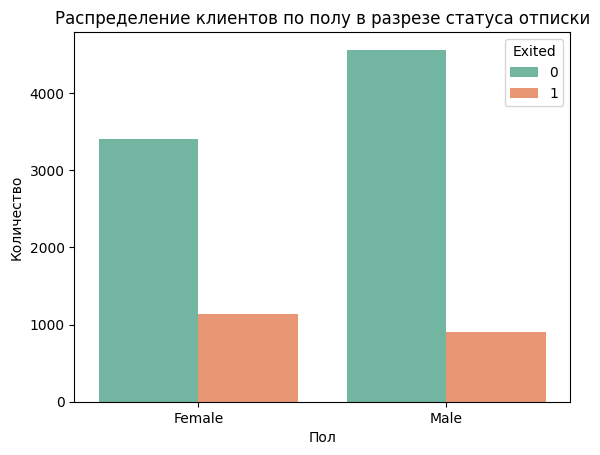

In [26]:
ax = sns.barplot(df.groupby(['Gender', 'Exited'], as_index=False).size(), x='Gender', y='size', hue='Exited')
ax.set_xlabel('Пол')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по полу в разрезе статуса отписки')

plt.show()

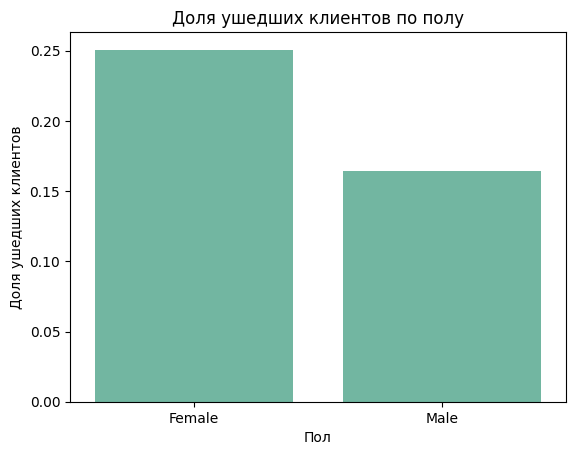

In [27]:
ax = sns.barplot(df.groupby(['Gender'], as_index=False).agg(Exited=('Exited', 'mean')), x='Gender', y='Exited')
ax.set_xlabel('Пол')
ax.set_ylabel('Доля ушедших клиентов')
ax.set_title('Доля ушедших клиентов по полу')

plt.show()

## Выводы

Обнаружена статистически значимая разница в доле ушедших клиентов среди женщин и мужчин. Женщины отказываются от банковских услуг чаще. Банку стоит выяснить причины и адаптировать продукт для женщин.

# Гипотеза №2

**Нулевая гипотеза (H0):** Связь между полом и оттоком одинакова во всех странах

**Альтернативная гипотеза (H1):** Связь между полом и оттоком различается в зависимости от страны

**Предпосылки.** Влияние пола на отток может отличаться из-за культурных особенностей страны. Например, в религиозных странах женщины меньше работают и распространены патриархальные семьи, что может сказаться на пользовании банковскими услгуами

**Способ проверки гипотезы:** логистическая регрессия с взаимодействием

**Уровень значимости:** 0.05

In [31]:
model = smf.logit("Exited ~ C(Gender) * C(Geography)", data=df).fit()

Optimization terminated successfully.
         Current function value: 0.486031
         Iterations 6


In [35]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9994
Method:                           MLE   Df Model:                            5
Date:                Sun, 04 May 2025   Pseudo R-squ.:                 0.03849
Time:                        10:46:21   Log-Likelihood:                -4860.3
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                 6.399e-82
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -1.3649      0.052    -26.126      0.000      -1.467      -1.262
C(Gender)[T.Male]                            -0.5617      0.077     -7.250      0.000      -0.714      -0.410
C(Geography)[T.Germany]                       0.8563      0.079     10.785      0.000       0.701       1.012
C(Geography)[T.Spain]                         0.0527      0.091      0.581      0.561      -0.125       0.230
C(Gender)[T.Male]:C(Geography)[T.Germany]     0.1164      0.116      1.007      0.314      -0.110       0.343
C(Gender)[T.Male]:C(Geography)[T.Spain]      -0.0172      0.133     -0.129      0.897      -0.279       0.244
=============================================================================================================
"""

## Выводы

Статистически значимого взаимодействия пола и страны не обнаружено (`p_value = 0.314` и `p_value = 0.897` при принятом уровне значимости 0.05)